# Modeling and Evaluation

In [92]:
# Library Imports.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

# Allows plots to appear directly in the notebook.
%matplotlib inline


In [93]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Formodeling.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonthIndex,Region_Encoded
0,62500.0,0,0,0,2016,7,140133.584455
1,150000.0,1,0,0,2016,12,198460.380569
2,94000.0,0,0,0,2016,8,140133.584455
3,149500.0,0,1,1,2016,2,78111.708000
4,170000.0,0,0,0,2016,10,101768.538462
5,50000.0,0,0,0,2016,12,169894.251731
6,15000.0,0,0,0,2016,10,486409.449362
7,160000.0,0,0,0,2016,8,139912.414348
8,320000.0,0,1,1,2016,12,178090.236923
9,225000.0,0,0,0,2016,5,357260.467719


In [94]:
df.dtypes

Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object

In [95]:
# Look at correlations for all the continuous features. 
# As SaleYear is kept for grouping, it is excluded. The feature of time is 'SaleMonthIndex'
df[['NotFullMarketPrice', 'VATExclusive', 'DescriptionofProperty','Price(€)','SaleMonthIndex', 'Region_Encoded']].corr()

,NotFullMarketPrice,VATExclusive,DescriptionofProperty,Price(€),SaleMonthIndex,Region_Encoded
NotFullMarketPrice,1.000000,0.012087,0.014065,-0.143274,0.024061,-0.016759
VATExclusive,0.012087,1.000000,0.990508,0.136223,0.041220,0.119929
DescriptionofProperty,0.014065,0.990508,1.000000,0.134008,0.040879,0.119274
Price(€),-0.143274,0.136223,0.134008,1.000000,0.234532,0.636500
SaleMonthIndex,0.024061,0.041220,0.040879,0.234532,1.000000,0.329981
Region_Encoded,-0.016759,0.119929,0.119274,0.636500,0.329981,1.000000


### Notice:
The correlation table shows a problem: the correlation between VATExclusive and DescriptionofProperty is as high as 0.99, indicating that these two features are nearly identical in the information they provide to the model. In the Irish property dataset, both fields essentially act as indicators for whether a property is a "New Build" (Subject to VAT) or "Second-hand". So in the medoling section, we decide to keep VATExclusive and drop DescriptionofProperty to remove the redundant feature to simplify the model and prevent the reduction of feature importance.

As the number of samples is huge, it looks messy if we use scatter. So here we use hexbin plot to show the correlation for each continuous descriptive feature and target feature. 

<Axes: xlabel='Region_Encoded', ylabel='Price(€)'>

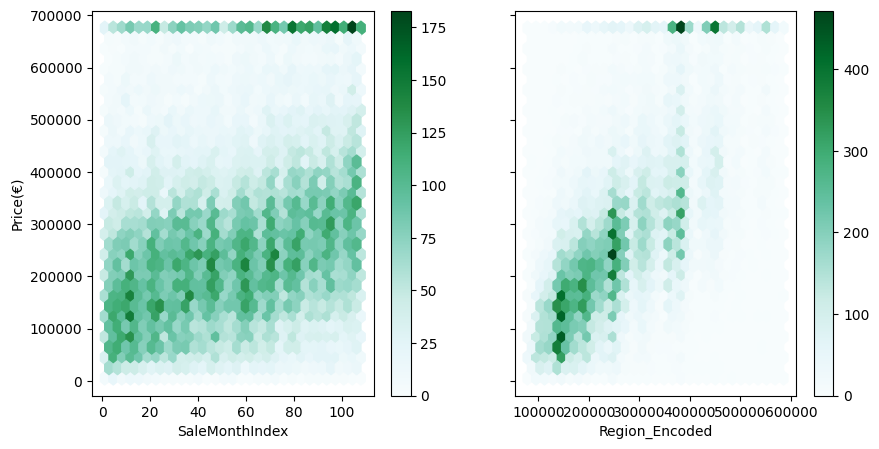

In [96]:

fig, axs = plt.subplots(1, 2, sharey=True)
df.plot(kind='hexbin', x='SaleMonthIndex', y='Price(€)', gridsize=30,label="%.3f" %df[['SaleMonthIndex', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[0], figsize=(10, 5))
df.plot(kind='hexbin', x='Region_Encoded', y='Price(€)', gridsize=30,label="%.3f" %df[['Region_Encoded', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[1])

The color shows the density in the area. And the hexbin plots show that both SaleMonthIndex and Region_Encoded have a roughly linear relationship with Price.

## Preparing the data with temporal split.
As price is time related, we split the training data into 5 groups of training dataset and validation dataset by year.<br>
The first group: 2016-2019 for training, 2020 for validation.<br>
The second group: 2017-2020 for training, 2021 for validation.<br>
The third group: 2018-2021 for training, 2022 for validation.<br>
The fourth group: 2019-2022 for training, 2023 for validation.<br>
The fifth group: 2020-2023 for training, 2024 for validation.

In [97]:
# Define descriptive features and target feature
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
target = 'Price(€)'

folds = []

# Define start_year, end_year and val_year (year for validation) of each group
group_configs = [
    (2016, 2019, 2020),
    (2017, 2020, 2021),
    (2018, 2021, 2022),
    (2019, 2022, 2023),
    (2020, 2023, 2024)
]

# start grouping
for i, (start_year, end_year, val_year) in enumerate(group_configs):
    # 1. pick out the samples of training data
    train_mask = (df['SaleYear'] >= start_year) & (df['SaleYear'] <= end_year)
    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    
    # 2. pick out the samples of validation data
    val_mask = df['SaleYear'] == val_year
    X_val = df.loc[val_mask, features]
    y_val = df.loc[val_mask, target]
    
    # 3. save the data set as dictionary and add into folds
    folds.append({
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'info': f"Group {i+1}: Train({start_year}-{end_year}) -> Val({val_year})"
    })
    
    print(f" {folds[i]['info']} | training data: {len(X_train)}, validation data: {len(X_val)}")

print("\nDone! Visiting the first group by folds[0]['X_train']")

 Group 1: Train(2016-2019) -> Val(2020) | training data: 23378, validation data: 5846
 Group 2: Train(2017-2020) -> Val(2021) | training data: 23361, validation data: 5859
 Group 3: Train(2018-2021) -> Val(2022) | training data: 23390, validation data: 5855
 Group 4: Train(2019-2022) -> Val(2023) | training data: 23395, validation data: 5861
 Group 5: Train(2020-2023) -> Val(2024) | training data: 23421, validation data: 5860

Done! Visiting the first group by folds[0]['X_train']


## Start modeling

### 

In [98]:
# This function is used repeatedly to compute, print and return the regression metrics
def getMetrics(testActualVal, predictions):
    mae=metrics.mean_absolute_error(testActualVal, predictions)
    rmse=metrics.mean_squared_error(testActualVal, predictions)**0.5
    r2=metrics.r2_score(testActualVal, predictions)
    print('\n==============================================================================')
    print("MAE: ", mae)
    #print("MSE: ", metrics.mean_squared_error(testActualVal, predictions))
    print("RMSE: ", rmse)
    print("R2: ", r2)
    return (mae,rmse,r2)

In [99]:
# Initialize variables for recording evaluation results
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
results=[]

In [100]:
# get baseline data
print('Baseline')

y=df[['Price(€)']]
baseline_pred = np.full(shape=y.shape[0], fill_value=y.mean())
(mae,rmse,r2)=getMetrics(y,baseline_pred)
results.append({
    'model':'Baseline',
    'MAE':mae,
    'RMSE':rmse,
    'R2':r2
})

Baseline

MAE:  130297.6506798358
RMSE:  165357.19324124232
R2:  0.0


### 1 Modeling with LinearRegression

In [101]:
from sklearn.linear_model import LinearRegression

print("Linear Regression")
errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # pick out the dataset
    X_train=fold['X_train']
    y_train=fold['y_train']
    X_val=fold['X_val']
    y_val=fold['y_val']

    # Train with linear regression model
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # Print the weights learned for each feature
    print("\nIntercept:\n", linreg.intercept_)
    print("Features and coefficients:", list(zip(features, linreg.coef_))[:10])

    # Predicted price on validation set
    pred = linreg.predict(X_val)
    
    (mae, rmse, r2) = getMetrics(y_val, pred)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': linreg.coef_
    })
    display(feature_importance.sort_values('importance', ascending=False)) 

# Print performance metrics
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average performance metrics
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])
results.append({
    'model':'Linear Regression',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print("\nAverage Performance of Linear Regression:")
print(results[-1])

Linear Regression
Group 1: Train(2016-2019) -> Val(2020)

Intercept:
 12740.170108234655
Features and coefficients: [('NotFullMarketPrice', np.float64(-89073.31777957431)), ('VATExclusive', np.float64(18234.112679097572)), ('SaleMonthIndex', np.float64(245.45447543564057)), ('Region_Encoded', np.float64(0.9674696375368512))]

MAE:  93306.42753483664
RMSE:  122870.65016932607
R2:  0.3892888231552871


,feature,importance
1,VATExclusive,18234.112679
2,SaleMonthIndex,245.454475
3,Region_Encoded,0.967470
0,NotFullMarketPrice,-89073.317780


Group 2: Train(2017-2020) -> Val(2021)

Intercept:
 29172.65373886266
Features and coefficients: [('NotFullMarketPrice', np.float64(-91053.19690349772)), ('VATExclusive', np.float64(24079.509079848758)), ('SaleMonthIndex', np.float64(-207.3981389563316)), ('Region_Encoded', np.float64(0.9623917886710842))]

MAE:  95430.08882238687
RMSE:  128509.73316965057
R2:  0.37662983708904463


,feature,importance
1,VATExclusive,24079.509080
3,Region_Encoded,0.962392
2,SaleMonthIndex,-207.398139
0,NotFullMarketPrice,-91053.196903


Group 3: Train(2018-2021) -> Val(2022)

Intercept:
 6508.644160424417
Features and coefficients: [('NotFullMarketPrice', np.float64(-97414.10518044965)), ('VATExclusive', np.float64(28322.20596674484)), ('SaleMonthIndex', np.float64(315.92032557538005)), ('Region_Encoded', np.float64(0.9622868314181687))]

MAE:  98877.26882829434
RMSE:  129299.49571788269
R2:  0.3839448028724407


...

Group 4: Train(2019-2022) -> Val(2023)

Intercept:
 -13503.249485537584
Features and coefficients: [('NotFullMarketPrice', np.float64(-100299.11840445145)), ('VATExclusive', np.float64(31124.024768599367)), ('SaleMonthIndex', np.float64(618.3838200858703)), ('Region_Encoded', np.float64(0.964744429129496))]

MAE:  103940.76700938387
RMSE:  131442.92841465882
R2:  0.35541036348154154


,feature,importance
1,VATExclusive,31124.024769
2,SaleMonthIndex,618.383820
3,Region_Encoded,0.964744
0,NotFullMarketPrice,-100299.118404


Group 5: Train(2020-2023) -> Val(2024)

Intercept:
 8292.299152804597
Features and coefficients: [('NotFullMarketPrice', np.float64(-107812.28858617261)), ('VATExclusive', np.float64(32546.740918537405)), ('SaleMonthIndex', np.float64(246.90347474944235)), ('Region_Encoded', np.float64(0.962582474181545))]

MAE:  103538.47919607341
RMSE:  131992.81146726976
R2:  0.3669578858548398


,feature,importance
1,VATExclusive,32546.740919
2,SaleMonthIndex,246.903475
3,Region_Encoded,0.962582
0,NotFullMarketPrice,-107812.288586


MAE: [93306.42753483664, 95430.08882238687, 98877.26882829434, 103940.76700938387, 103538.47919607341]
RMSE: [122870.65016932607, 128509.73316965057, 129299.49571788269, 131442.92841465882, 131992.81146726976]
R2: [0.3892888231552871, 0.37662983708904463, 0.3839448028724407, 0.35541036348154154, 0.3669578858548398]

Average Performance of Linear Regression:
{'model': 'Linear Regression', 'MAE': 99018.60627819502, 'RMSE': 128823.12378775756, 'R2': 0.37444634249063075}


The Linear Regression model shows moderate performance. The average MAE of 99018.6 indicates that there is a noticeable gap between the predicted and actual property prices. Similarly, the RMSE of 128823.12 suggests that some predictions have relatively large errors.

The R² value is around 0.37, meaning the model explains about 37% of the variation in property prices. While this shows that the model captures some patterns in the data, its overall explanatory power is still limited.

This may suggest a degree of underfitting, as the linear model is likely too simple to capture more complex relationships in the dataset. In addition, the limited number of features may also restrict the model’s performance.

### 2 Modeling with Lasso

In [102]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

print("Lasso")

errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # pick out the dataset
    X_train=fold['X_train']
    y_train=fold['y_train']
    X_val=fold['X_val']
    y_val=fold['y_val']

    # Standardise numeric features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train with Lasso model
    lasso = Lasso(alpha=0.001) 
    lasso.fit(X_train_scaled, y_train)
    
    # Print the weights learned for each feature
    print("\nIntercept:\n", lasso.intercept_)
    print("Features and coefficients:", list(zip(features, lasso.coef_))[:10])

    # Predicted price on validation set
    pred = lasso.predict(X_val_scaled)

    (mae, rmse, r2) = getMetrics(y_val, pred)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': lasso.coef_
    })
    display(feature_importance.sort_values('importance', ascending=False)) 

# Print performance metrics
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average performance metrics
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])
results.append({
    'model':'Lasso',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print("\nAverage Performance of Lasso:")
print(results[-1])

Lasso
Group 1: Train(2016-2019) -> Val(2020)

Intercept:
 244939.4324488836
Features and coefficients: [('NotFullMarketPrice', np.float64(-19366.594896369916)), ('VATExclusive', np.float64(6847.780980904353)), ('SaleMonthIndex', np.float64(3389.793238563542)), ('Region_Encoded', np.float64(99022.43323471666))]

MAE:  93306.42715808646
RMSE:  122870.65007973902
R2:  0.3892888240458465


,feature,importance
3,Region_Encoded,99022.433235
1,VATExclusive,6847.780981
2,SaleMonthIndex,3389.793239
0,NotFullMarketPrice,-19366.594896


Group 2: Train(2017-2020) -> Val(2021)

Intercept:
 256881.6029386584
Features and coefficients: [('NotFullMarketPrice', np.float64(-20483.255436896547)), ('VATExclusive', np.float64(9336.79120312456)), ('SaleMonthIndex', np.float64(-2888.7666451721093)), ('Region_Encoded', np.float64(97309.71834241449))]

MAE:  95430.08895952794
RMSE:  128509.73293698301
R2:  0.3766298393462747


,feature,importance
3,Region_Encoded,97309.718342
1,VATExclusive,9336.791203
2,SaleMonthIndex,-2888.766645
0,NotFullMarketPrice,-20483.255437


Group 3: Train(2018-2021) -> Val(2022)

Intercept:
 267452.7250555793
Features and coefficients: [('NotFullMarketPrice', np.float64(-21884.82453019125)), ('VATExclusive', np.float64(10970.692134569814)), ('SaleMonthIndex', np.float64(4388.054917737587)), ('Region_Encoded', np.float64(95592.2588179928))]

MAE:  98877.26866724248
RMSE:  129299.49577829208
R2:  0.3839448022967923


...

Group 4: Train(2019-2022) -> Val(2023)

Intercept:
 282112.37306432996
Features and coefficients: [('NotFullMarketPrice', np.float64(-22195.084894333275)), ('VATExclusive', np.float64(11864.503622025239)), ('SaleMonthIndex', np.float64(8544.07682058667)), ('Region_Encoded', np.float64(95896.34229857168))]

MAE:  103940.76659508706
RMSE:  131442.92813216645
R2:  0.3554103662521988


,feature,importance
3,Region_Encoded,95896.342299
1,VATExclusive,11864.503622
2,SaleMonthIndex,8544.076821
0,NotFullMarketPrice,-22195.084894


Group 5: Train(2020-2023) -> Val(2024)

Intercept:
 297820.0857836984
Features and coefficients: [('NotFullMarketPrice', np.float64(-23901.05686602101)), ('VATExclusive', np.float64(12450.78449116)), ('SaleMonthIndex', np.float64(3392.598380158102)), ('Region_Encoded', np.float64(96840.91040266957))]

MAE:  103538.47905038428
RMSE:  131992.81143482096
R2:  0.36695788616609093


,feature,importance
3,Region_Encoded,96840.910403
1,VATExclusive,12450.784491
2,SaleMonthIndex,3392.598380
0,NotFullMarketPrice,-23901.056866


MAE: [93306.42715808646, 95430.08895952794, 98877.26866724248, 103940.76659508706, 103538.47905038428]
RMSE: [122870.65007973902, 128509.73293698301, 129299.49577829208, 131442.92813216645, 131992.81143482096]
R2: [0.3892888240458465, 0.3766298393462747, 0.3839448022967923, 0.3554103662521988, 0.36695788616609093]

Average Performance of Lasso:
{'model': 'Lasso', 'MAE': 99018.60608606564, 'RMSE': 128823.1236724003, 'R2': 0.37444634362144064}


The Lasso model shows a similar level of performance to Linear Regression. The average MAE of around 99,018 indicates a noticeable difference between predicted and actual property prices, while the RMSE of 128,823 suggests that some predictions still have relatively large errors.

The R² value is approximately 0.37, meaning the model explains about 37% of the variation in property prices. This indicates that Lasso is able to capture some underlying patterns in the data, but its overall explanatory power remains limited.

Compared to Linear Regression, Lasso does not provide a clear improvement in performance. This may be because the dataset does not contain a large number of irrelevant features, so the regularisation effect of Lasso does not significantly enhance the model.

Overall, the model may still be underfitting, as it is unable to capture more complex relationships in the data.

### 3 Modeling with RidgeCV

In [103]:
from sklearn.linear_model import RidgeCV

print("Ridge")
errors={
    'MAE':[],
    'RMSE':[],
    'R2':[]
    }
for fold in folds:
    # print the info of current group
    print('='*70)
    print(fold['info'])

    # pick out the dataset
    X_train_unscaled=fold['X_train']
    y_train=fold['y_train']
    X_val_unscaled=fold['X_val']
    y_val=fold['y_val']

    # Standardise numeric features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_unscaled)
    X_val = scaler.transform(X_val_unscaled)

    # train the model
    ridge = RidgeCV()
    ridge.fit(X_train, y_train)

    # Print the weights learned for each feature.
    print("\nIntercept: \n", ridge.intercept_)
    print("Features and coeficients:", list(zip(features, ridge.coef_))[:10])
  
    # Predicted price on validation set
    pred = ridge.predict(X_val)
    (mae,rmse,r2)=getMetrics(y_val, pred)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    feature_importance = pd.DataFrame({'feature': features, 'importance':ridge.coef_})
    display(feature_importance.sort_values('importance', ascending=False))

Ridge
Group 1: Train(2016-2019) -> Val(2020)

Intercept: 
 244939.4324488836
Features and coeficients: [('NotFullMarketPrice', np.float64(-19359.202807383957)), ('VATExclusive', np.float64(6850.924690260032)), ('SaleMonthIndex', np.float64(3393.560507902148)), ('Region_Encoded', np.float64(98979.27267948634))]

MAE:  93306.84527618805
RMSE:  122870.59762674318
R2:  0.38928934546611915


,feature,importance
3,Region_Encoded,98979.272679
1,VATExclusive,6850.924690
2,SaleMonthIndex,3393.560508
0,NotFullMarketPrice,-19359.202807


Group 2: Train(2017-2020) -> Val(2021)

Intercept: 
 256881.6029386584
Features and coeficients: [('NotFullMarketPrice', np.float64(-20475.82533836599)), ('VATExclusive', np.float64(9339.145781674591)), ('SaleMonthIndex', np.float64(-2881.7801085032897)), ('Region_Encoded', np.float64(97266.95459699837))]

MAE:  95431.64713932386
RMSE:  128510.53521513793
R2:  0.37662205600081144


,feature,importance
3,Region_Encoded,97266.954597
1,VATExclusive,9339.145782
2,SaleMonthIndex,-2881.780109
0,NotFullMarketPrice,-20475.825338


Group 3: Train(2018-2021) -> Val(2022)

Intercept: 
 267452.7250555793
Features and coeficients: [('NotFullMarketPrice', np.float64(-21876.832271641164)), ('VATExclusive', np.float64(10971.18444925794)), ('SaleMonthIndex', np.float64(4389.232538498705)), ('Region_Encoded', np.float64(95551.52507077702))]

MAE:  98877.30203396124
RMSE:  129299.7486447668
R2:  0.38394239269948527


,feature,importance
3,Region_Encoded,95551.525071
1,VATExclusive,10971.184449
2,SaleMonthIndex,4389.232538
0,NotFullMarketPrice,-21876.832272


Group 4: Train(2019-2022) -> Val(2023)

Intercept: 
 282112.37306432996
Features and coeficients: [('NotFullMarketPrice', np.float64(-22186.712085399875)), ('VATExclusive', np.float64(11863.515728509872)), ('SaleMonthIndex', np.float64(8544.936604103319)), ('Region_Encoded', np.float64(95855.62099677125))]

MAE:  103938.57742136286
RMSE:  131439.69053610106
R2:  0.3554421198838318


,feature,importance
3,Region_Encoded,95855.620997
1,VATExclusive,11863.515729
2,SaleMonthIndex,8544.936604
0,NotFullMarketPrice,-22186.712085


Group 5: Train(2020-2023) -> Val(2024)

Intercept: 
 297820.0857836984
Features and coeficients: [('NotFullMarketPrice', np.float64(-23892.005942323318)), ('VATExclusive', np.float64(12449.240885922603)), ('SaleMonthIndex', np.float64(3399.968771223994)), ('Region_Encoded', np.float64(96798.41892730657))]

MAE:  103539.01519983717
RMSE:  131992.3571561623
R2:  0.3669622436310823


,feature,importance
3,Region_Encoded,96798.418927
1,VATExclusive,12449.240886
2,SaleMonthIndex,3399.968771
0,NotFullMarketPrice,-23892.005942


The intercept represents the baseline price when all features are zero. The feature coefficients show how each variable affects the predicted property price.

Taking Group 5 as an example, the model can be written as:

price = 297820.09 + 12449.24 × VATExclusive + 3399.97 × SaleMonthIndex + 96798.42 × Region_Encoded − 23892.01 × NotFullMarketPrice

From this, we can interpret the impact of each feature:

1. VATExclusive (12449.24): If a property is VAT exclusive, the predicted price increases by about €12,449 compared to the baseline.

2. SaleMonthIndex (3399.97): This suggests that property prices tend to increase over time, with an estimated rise of about €3,400 per month index.

3. Region_Encoded (96798.42): This has the strongest positive effect. It indicates that properties in higher-value regions are associated with significantly higher prices.

4. NotFullMarketPrice (-23892.01): If a property is not sold at full market price, the predicted price decreases by about €23,892.

Overall, Region_Encoded appears to be the most influential feature, while NotFullMarketPrice has a clear negative impact on property values.

In [104]:
print('MAE:',errors['MAE'])
print('RMSE:',errors['RMSE'])
print('R2:',errors['R2'])

mean_mae=sum(errors['MAE'])/len(errors['MAE'])
mean_rmse=sum(errors['RMSE'])/len(errors['RMSE'])
mean_r2=sum(errors['R2'])/len(errors['R2'])
results.append({
    'model':'RidgeCV',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print(results[-1])

MAE: [93306.84527618805, 95431.64713932386, 98877.30203396124, 103938.57742136286, 103539.01519983717]
RMSE: [122870.59762674318, 128510.53521513793, 129299.7486447668, 131439.69053610106, 131992.3571561623]
R2: [0.38928934546611915, 0.37662205600081144, 0.38394239269948527, 0.3554421198838318, 0.3669622436310823]
{'model': 'RidgeCV', 'MAE': 99018.67741413464, 'RMSE': 128822.58583578226, 'R2': 0.374451631536266}


The Ridge Regression model performs at a nearly identical level to both Linear Regression and Lasso, with an average MAE of 99,019 and an RMSE of 128,823. The gap between these two metrics consistently points to the presence of high-value outliers that remain difficult for linear-based models to predict accurately.

The R² value is approximately 0.37, indicating that the model explains 37% of the price variation. While Ridge is effective at capturing the general linear trends in the Irish housing market, its explanatory power is still hitting a plateau.

Compared to the previous models, Ridge does not show a significant leap in performance. This suggests that while L2 regularization helps in stabilizing the coefficients, the primary challenge is not feature multicollinearity or overfitting, but rather a lack of complex, non-linear predictors.

Overall, the model remains limited by the existing feature set. The fact that Ridge, Lasso, and Linear Regression all converge at the same 0.37 mark suggests that we have likely reached the maximum predictive capacity for any linear approach with this specific dataset.

### 4 Modeling with Random Forest

In [105]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest")

# Store evaluation results for each fold
errors = {
    'MAE': [],
    'RMSE': [],
    'R2': []
}

# Store feature importance from each fold
rf_feature_importances = []

# Loop through each time-based fold
for fold in folds:
    print('=' * 70)
    print(fold['info'])

    # Get training and validation data for this fold
    X_train=fold['X_train']
    y_train=fold['y_train']
    X_val=fold['X_val']
    y_val=fold['y_val']


    # Build Random Forest model
    # n_estimators: number of trees
    # max_depth: maximum depth of each tree
    # min_samples_split / min_samples_leaf: help reduce overfitting
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # Train model using log-transformed target
    rf_model.fit(X_train, y_train)

    # Predict log_price on validation set
    pred = rf_model.predict(X_val)

    # Evaluate predictions against original price
    mae, rmse, r2 = getMetrics(y_val, pred)

    # Save fold metrics
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    # Save feature importance for this fold
    rf_feature_importances.append(rf_model.feature_importances_)

# Print metrics from all folds
print('MAE:', errors['MAE'])
print('RMSE:', errors['RMSE'])
print('R2:', errors['R2'])

# Calculate average metrics across all folds
mean_mae = sum(errors['MAE']) / len(errors['MAE'])
mean_rmse = sum(errors['RMSE']) / len(errors['RMSE'])
mean_r2 = sum(errors['R2']) / len(errors['R2'])

# Save final averaged result into results list
results.append({
    'model': 'Random Forest',
    'MAE': mean_mae,
    'RMSE': mean_rmse,
    'R2': mean_r2
})

print("\nAverage Random Forest Performance:")
print(results[-1])

# Calculate average feature importance across all folds
mean_importance = np.mean(rf_feature_importances, axis=0)

rf_importance_df = pd.DataFrame({
    'feature': features,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

print("\nAverage Feature Importance (Random Forest):")
display(rf_importance_df)

Random Forest
Group 1: Train(2016-2019) -> Val(2020)

MAE:  92334.09071224774
RMSE:  123508.940478946
R2:  0.38292727914584923
Group 2: Train(2017-2020) -> Val(2021)

MAE:  97950.76860390053
RMSE:  129916.49593110259
R2:  0.3629073945263477
Group 3: Train(2018-2021) -> Val(2022)

MAE:  101695.0285972864
RMSE:  131783.7457764224
R2:  0.36004467259194906
Group 4: Train(2019-2022) -> Val(2023)

MAE:  106192.75287366979
RMSE:  133982.8427368386
R2:  0.33025845053294967
Group 5: Train(2020-2023) -> Val(2024)

MAE:  105188.22737228866
RMSE:  133545.0991789385
R2:  0.3519806800568973
MAE: [92334.09071224774, 97950.76860390053, 101695.0285972864, 106192.75287366979, 105188.22737228866]
RMSE: [123508.940478946, 129916.49593110259, 131783.7457764224, 133982.8427368386, 133545.0991789385]
R2: [0.38292727914584923, 0.3629073945263477, 0.36004467259194906, 0.33025845053294967, 0.3519806800568973]

Average Random Forest Performance:
{'model': 'Random Forest', 'MAE': 100672.17363187861, 'RMSE': 13054

,feature,importance
3,Region_Encoded,0.866372
2,SaleMonthIndex,0.065781
0,NotFullMarketPrice,0.049097
1,VATExclusive,0.018750


The Random Forest model shows a similar level of performance to the other models. The R² score is around 0.36, meaning it explains about 36% of the variation in house prices.

The MAE and RMSE values are also relatively high, suggesting that prediction errors are still quite large.

From the feature importance results, it is clear that the model relies heavily on Region_Encoded, which contributes most of the predictive power. Other features such as SaleMonthIndex, NotFullMarketPrice, and VATExclusive have much smaller impacts.

This suggests that the model is not making full use of all available features, and is mainly driven by location-related information. As a result, the overall performance remains limited.

In [106]:
results_df = pd.DataFrame(results).sort_values('R2',ascending=False)
results_df

,model,MAE,RMSE,R2
3,RidgeCV,99018.677414,128822.585836,0.374452
2,Lasso,99018.606086,128823.123672,0.374446
1,Linear Regression,99018.606278,128823.123788,0.374446
4,Random Forest,100672.173632,130547.424820,0.357624
0,Baseline,130297.650680,165357.193241,0.000000


On the train data set, Linear Regression, Lasso and RidgeCV (all linear) have the same perform. Random Forest performs a little bit worse than linear regression models, but still similar. So here we choose the RidgeCV as the final model.

### 5 Modeling with Pipeline

In [107]:
from sklearn.pipeline import Pipeline

print("RidgeCV with Pipeline (Full Training Set)")

# Define descriptive features and target feature
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
target = 'Price(€)'

# Use the full training dataset
X = df[features]
y = df[target]

# Build pipeline: scaling + RidgeCV
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RidgeCV(alphas=np.logspace(-3, 3, 13)))
])

# Train pipeline on the full training set
ridge_pipe.fit(X, y)

# Predict on the same training set
pred = ridge_pipe.predict(X)

# Evaluate training performance
mae, rmse, r2 = getMetrics(y, pred)

results.append({
    'model': 'RidgeCV Pipeline (Full Training Set)',
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
})

print("\nTraining Performance of RidgeCV Pipeline (Full Training Set):")
print(results[-1])

# Print model details
ridge_model = ridge_pipe.named_steps['reg']
print("\nSelected alpha:", ridge_model.alpha_)
print("Intercept:\n", ridge_model.intercept_)
print("Features and coefficients:", list(zip(features, ridge_model.coef_)))

# Feature importance / coefficients
ridge_importance_df = pd.DataFrame({
    'feature': features,
    'importance': ridge_model.coef_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (RidgeCV Pipeline) (Full Training Set) :")
display(ridge_importance_df)



RidgeCV with Pipeline (Full Training Set)

MAE:  95018.10762662241
RMSE:  125116.00744851446
R2:  0.4274946222732112

Training Performance of RidgeCV Pipeline (Full Training Set):
{'model': 'RidgeCV Pipeline (Full Training Set)', 'MAE': 95018.10762662241, 'RMSE': 125116.00744851446, 'R2': 0.4274946222732112}

Selected alpha: 3.1622776601683795
Intercept:
 279646.8737218709
Features and coefficients: [('NotFullMarketPrice', np.float64(-22234.37056846846)), ('VATExclusive', np.float64(10356.762875195825)), ('SaleMonthIndex', np.float64(5267.177715049693)), ('Region_Encoded', np.float64(101890.93241698512))]

Feature Importance (RidgeCV Pipeline) (Full Training Set) :


,feature,importance
3,Region_Encoded,101890.932417
1,VATExclusive,10356.762875
2,SaleMonthIndex,5267.177715
0,NotFullMarketPrice,-22234.370568


The formular for predicting is:
price=279646.8737218709+10356.762875\*VATExclusive+5267.177715\*SaleMonthIndex+101890.932450\*Region_Encoded-22234.370568\*NotFullMarketPrice<br>

1,Intercept is 279646.8737218709, which is the base value. <br>

2,VATExclusive:10356.762875. It means if the property is VATExclusive, it adds €10356.762875 to the base value.<br>

3,SaleMonthIndex: 5267.177715. It means the price grows by €5267.177715 by month.<br>

4,Region_Encoded: 101890.932417. It means adding €101890.932417 timed by the scaled Region_Encoded value to the base value.<br>

5,NotFullMarketPrice:-22234.370568. It means if the property is NotFullMarketPrice, the price declines by €22234.370568<br>

### 6. Evaluation


In [108]:
# Reading from a csv file, into a data frame
df_test = pd.read_csv('ppr-group-25204989-test-Forevaluation.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df_test.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonthIndex,Region_Encoded
0,2525000.00,0,0,0,2025,120,543378.937302
1,260000.00,0,0,0,2025,118,229921.623040
2,361233.00,0,1,1,2025,120,299132.044691
3,435000.00,0,0,0,2025,114,412896.226415
4,334000.00,0,0,0,2025,119,285224.814920
5,390000.00,0,0,0,2025,119,354279.664683
6,845814.97,0,1,1,2025,117,466855.762541
7,282000.00,0,0,0,2025,109,266956.674667
8,550000.00,0,0,0,2025,112,320858.648413
9,400000.00,0,0,0,2025,118,332809.963642


In [109]:
# Predict on the test set
print("Evaluation with full test set")

X_test = df_test[features]
y_test = df_test[target]

pred = ridge_pipe.predict(X_test)

# Evaluate training performance
mae, rmse, r2 = getMetrics(y_test, pred)

results.append({
    'model': 'RidgeCV Pipeline (Full Test Set)',
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
})

print("\nTraining Performance of RidgeCV Pipeline (Full Test Set):")
print(results[-1])



Evaluation with full test set

MAE:  150409.81265783173
RMSE:  672381.5640674933
R2:  0.030926268176194704

Training Performance of RidgeCV Pipeline (Full Test Set):
{'model': 'RidgeCV Pipeline (Full Test Set)', 'MAE': 150409.81265783173, 'RMSE': 672381.5640674933, 'R2': 0.030926268176194704}


To reduce the impact of extreme outliers, we applied a clamping strategy to the training data, which helped make the model more stable. However, in order to prevent data leakage, the clampping action was not applied to the test data, leading to a difference in the distribution of the target variable between training and testing. This inconsistency may partly explain the drop in model performance.

As a result, the model tends to predict values closer to the average price level and often underestimates high-priced properties. The large errors associated with these high-value cases have a strong impact on the evaluation results, which leads to a lower R² score.

In practice, this suggests that the model is better suited as a standard residential price predictor, where it captures general trends in the mainstream housing market. It is less reliable for the luxury segment, where prices are more extreme and influenced by additional factors that are not represented in the dataset.

To prove this, we take the clamped test data set for evaluation as below.

In [110]:
# Reading from a csv file, into a data frame
df_test = pd.read_csv('ppr-group-25204989-test-Forevaluation-clamped.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df_test.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonthIndex,Region_Encoded
0,779240.085,0,0,0,2025,120,543378.937302
1,260000.000,0,0,0,2025,118,229921.623040
2,361233.000,0,1,1,2025,120,299132.044691
3,435000.000,0,0,0,2025,114,412896.226415
4,334000.000,0,0,0,2025,119,285224.814920
5,390000.000,0,0,0,2025,119,354279.664683
6,779240.085,0,1,1,2025,117,466855.762541
7,282000.000,0,0,0,2025,109,266956.674667
8,550000.000,0,0,0,2025,112,320858.648413
9,400000.000,0,0,0,2025,118,332809.963642


In [111]:
# Predict on the test set
print("Evaluation with clamped test set")

X_test = df_test[features]
y_test = df_test[target]

pred = ridge_pipe.predict(X_test)

# Evaluate training performance
mae, rmse, r2 = getMetrics(y_test, pred)

results.append({
    'model': 'RidgeCV Pipeline (Clamped Test Set)',
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
})

print("\nTraining Performance of RidgeCV Pipeline (Clamped Test Set):")
print(results[-1])


Evaluation with clamped test set

MAE:  113174.35697745846
RMSE:  148914.3418503812
R2:  0.3241089940591094

Training Performance of RidgeCV Pipeline (Clamped Test Set):
{'model': 'RidgeCV Pipeline (Clamped Test Set)', 'MAE': 113174.35697745846, 'RMSE': 148914.3418503812, 'R2': 0.3241089940591094}





Here the R2 improved to 0.32, which means the model explains 32% of the price variance in the core residential market. MAE is 113174.35697745846, which means the avarage mistake between predicted prices and real prices is about €113174. RMSE is 148914.3418503812, higher than the MAE, indicating that the model's performance is affected by large variance in errors.


Overall, an R2 of 0.32 is still not very high. This is because the limitation comes from the dataset itself. Property prices are affected by many factors, such as property size, number of rooms, energy efficiency, floor level, and layout. Since these important features are not included in the data, the model cannot fully capture the complexity of how property prices are determined.